In [1]:
# Importamos las librerías comunes
import pandas as pd
import numpy as np
import scipy.stats as scipystats
from scipy.stats import kurtosis, norm, skew
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

### 3. Exploratory Data Analysis
El objetivo través de la exploración de datos es comprender la estructura, calidad y comportamiento estadístico de los datos **Home Equity Loan (hmeq)**. Es un paso crítico antes de tomar cualquier decisión en el preprocesamiento o modelización.   
El EDA esta centrado con el objetivo principal del TFM (punto 1.2), estimar la **Probabilidad de Incumplimiento (PD – Probability of Default)** de una cartera de préstamos con garantía hipotecaria con el fin de <u> predecir la probabilidad de que un prestatario incurra en impago. </u>    

El análisis se estructura de forma progresiva:  
<small>

|  Análisis  | Descripción
|----------|:---------|
| **Visión general del dataset**  | Revisar la dimensión, estructura, clasificación funcional tipología de variables
| **Análisis de la variable objetivo** |  Definición de la variable objetivo BAD
| **Análisis univariante** |  Examinar medidas de centralización, dispersión, forma de las distribuciones, asimetría y curtosis.
| **Calidad del dato** | Missing values y outliers por variable
| **Análisis multivariante** |  evaluar la relación entre las variables explicativas y la variable objetivo asi como detectar problemas de colinealidad.

</small>

El EDA servirá como base para el desarrollo de modelos de clasificación probabilística, empleando como modelo de referencia una regresión logística. Sobre esta base, se explorará posteriormente el uso de modelos (Decision Tree, Random Forest, Gradient Boosting) siempre con el objetivo principal de comparar el rendimiento predictivo y la capacidad de estimación de probabilidades.

#### 3.1 Visión general del dataset

In [2]:
# Cargar el dataset y mostrar algunas filas.
hmeq = pd.read_csv('../data/raw/hmeq.csv')
hmeq.head(4)

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



El dataset HMEQ (Home Equity Loans) recoge información histórica sobre una cartera de préstamos concedidos con garantía sobre el valor de la vivienda del prestatario. Este tipo de productos es habitual en carteras retail hipotecarias, donde el colateral inmobiliario juega un papel relevante en el perfil de riesgo.  
Cada fila del conjunto de datos corresponde a una solicitud u operación de préstamo, para la cual se dispone de información financiera, laboral y de comportamiento crediticio, así como del estado de impago reflejado en la variable objetivo.

In [3]:
print("Informacion del dataset:")
hmeq.info()

Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


- Tenemos <u> 5960 registros con 13 columnas </u>, donde hay missing values en 10 columnas: Todas excepto la variable target (BAD) y el importe del prestamo (LOAN).   
- Respecto a la tipología de variable, tan solo la finalidad del préstamo **(REASON) y JOB son categóricas** mientras que el **resto son numéricas**.
- Atendiendo a la descripción funcional de la variables explicativas parece que todas van a jugar un papel considerable en la clasificación de la variable objetivo BAD.  

<span style="font-size:14px">

|  Variable |  Grupo funcional | Descripción
|----------|:---------|:---------|
| BAD  | Objetivo | Indica si el cliente ha incumplido (1) o no (0) en el pago del préstamo
| LOAN | Financieras | Importe del préstamo solicitado
| MORTDUE | Financieras | Saldo pendiente de la hipoteca existente
| DEBTINC | Financieras | Ratio deuda-ingresos del prestatario
| VALUE | Financieras | Valor estimado de la propiedad
| DEROG |Comportamiento crediticio | Número de incidencias crediticias graves
| DELINQ |Comportamiento crediticio | Número de líneas de crédito en mora
| NINQ |Comportamiento crediticio | Número de consultas recientes de crédito
| CLAGE |Comportamiento crediticio | Antigüedad de la línea de crédito más antigua (meses)
| CLNO |Comportamiento crediticio | Número total de líneas de crédito
| REASON |Financieras | Finalidad del préstamo
| YOJ |Laborales | Años en el empleo actual
| JOB |Laborales | Categoría ocupacional del prestatario

<span>




#### 3.2 Análisis de la variable objetivo

In [4]:
# Análisis de la variable objetivo 'BAD'
target = hmeq['BAD']
target_sano = target[target == 0].count() / target.count() * 100
target_malo = target[target == 1].count() / target.count() * 100
print(f'La muestra contiene un {target_sano:.2f}% de clientes al corriente de pago mientras que un {target_malo:.2f}% son default')

La muestra contiene un 80.05% de clientes al corriente de pago mientras que un 19.95% son default


In [5]:
target

0       1
1       1
2       1
3       1
4       0
       ..
5955    0
5956    0
5957    0
5958    0
5959    0
Name: BAD, Length: 5960, dtype: int64

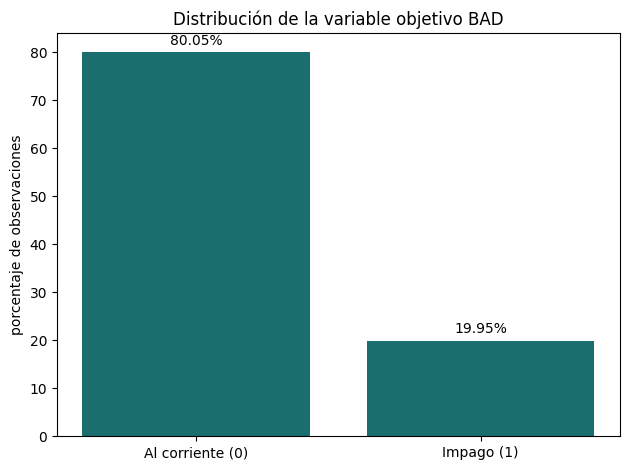

In [6]:
# 1. Calcular frecuencias de la variable BAD
counts = target.value_counts(normalize=True)*100

# 2. Dibujar las barras con el color seleccionado
bars = plt.bar(["Al corriente (0)", "Impago (1)"], counts.values, color="#1B6E6E")

# 3. Añadir el número de observaciones directamente encima de cada barra
plt.bar_label(bars,  fmt="%.2f%%",  padding=3)

# 4. Títulos mínimos obligatorios
plt.title("Distribución de la variable objetivo BAD")
plt.ylabel("porcentaje de observaciones")
plt.tight_layout()
plt.savefig("distribucion_bad_ultra.png")

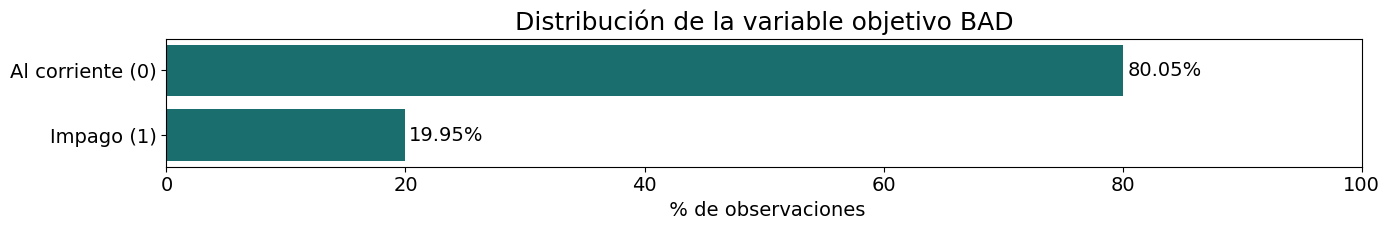

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 2.4))
# 1. Calcular el porcentaje de cada clase de BAD (proporciones * 100)
counts = target.value_counts(normalize=True) * 100

# 2. Ordenar por índice para asegurar que el orden es 0 y luego 1
counts = counts.sort_index()

# 3. Etiquetas legibles para cada clase
etiquetas = ["Al corriente (0)", "Impago (1)"]

# 4. Dibujar las barras HORIZONTALES con el color de marca
barras = plt.barh(etiquetas, counts.values, color="#1B6E6E")

# 5. Poner "Al corriente (0)" arriba (barh empieza por abajo, así que invertimos el eje)
plt.gca().invert_yaxis()

# 6. Escribir el porcentaje al final de cada barra (Aumentamos fontsize a 14)
plt.bar_label(barras, fmt="%.2f%%", padding=3, fontsize=14)

# 7. Títulos mínimos (Aumentamos fontsize a 16 y ponemos negrita)
plt.title("Distribución de la variable objetivo BAD", fontsize=18)
plt.xlabel(" % de observaciones", fontsize=14)

# NUEVO: Aumentar el tamaño de la fuente de los valores de los ejes X e Y a 14
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# 8. Margen a la derecha para que no se corte la etiqueta del porcentaje
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

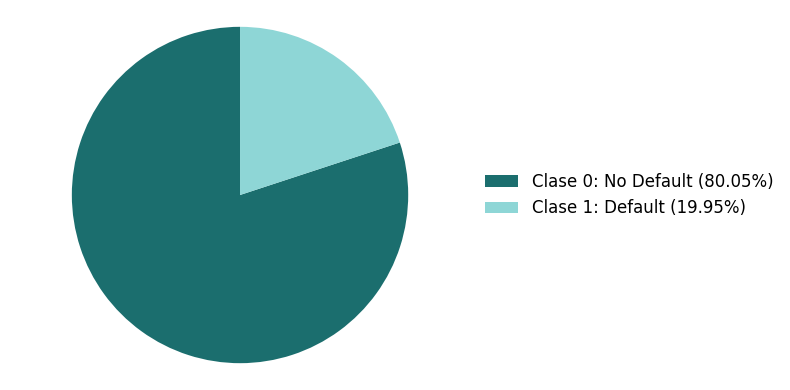

In [8]:
import matplotlib.pyplot as plt

# 1. Calcular el porcentaje de cada clase (0 y 1)
counts = target.value_counts(normalize=True) * 100
counts = counts.sort_index()

# 2. Definir los colores: tu color corporativo para No Default y rojo para Default
colores = ["#1B6E6E", "#8ED6D6"] 

# 3. Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 4))

# 4. Dibujar el gráfico circular (sin etiquetas de texto internas para imitar tu imagen)
wedges, texts = ax.pie(counts, colors=colores, startangle=90)

# 5. Crear las etiquetas de texto exactas para la leyenda externa
etiquetas_leyenda = [f"Clase 0: No Default ({counts[0]:.2f}%)",
                     f"Clase 1: Default ({counts[1]:.2f}%)"]

# 6. Configurar y posicionar la leyenda a la derecha del gráfico
ax.legend(wedges, etiquetas_leyenda, title="", loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=12)

# 7. Asegurar que el gráfico sea un círculo perfecto
ax.axis('equal')

# 8. Ajustar los márgenes y mostrar
plt.tight_layout()
plt.savefig("distribucion_bad_circular.png", dpi=150)
plt.show()

La variable BAD presenta una distribución claramente desbalanceada, con aproximadamente un 80 % de préstamos al corriente de pago (BAD = 0) frente a un 20 % en situación de impago (BAD = 1). Este comportamiento es consistente con carteras reales de crédito retail, donde los eventos de default son relativamente infrecuentes.
Este **desbalanceo** tiene implicaciones metodológicas relevantes. Ante estos problemas, la métrica **accuracy** deja de ser efectivo para medir desempeño global del modelo pues cuantifica el porcentaje de predicciones correctas y en problemas desbalanceados no es correcto. Si el modelo identificase todos los registros al corriente de pago y no detectase falsos negativos (clientes realmente en default), tendría una accuracy del 80% y esto provocaría un riesgo real de crédito para la entidad financiera.  
Por lo tanto, la evaluación se basará en métricas más apropiadas para problemas de clasificación desbalanceada y estimación de probabilidades, tales como **el área bajo la curva ROC (AUC), el coeficiente de Gini, el Brier Score y el análisis de calibración**. Estas métricas permiten evaluar tanto la capacidad discriminante del modelo como la calidad de las probabilidades estimadas, aspectos clave en la modelización de la Probabilidad de Incumplimiento (PD).


In [9]:
num_vars_target = hmeq.select_dtypes('number')
spearman_corr = num_vars_target.corr(method='spearman')
corr_with_target = spearman_corr['BAD'].sort_values(ascending=False)
# Dataframe
corr_with_target = corr_with_target.reset_index().rename(columns={'index': 'Variable', 'BAD': 'Correlación con BAD'})


#### 3.3 Análisis univariante

In [10]:
print("Resumen estadístico del dataset:")
hmeq.describe().round(2)

Resumen estadístico del dataset:


,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.0,5960.00,5442.00,5848.00,5445.00,5252.00,5380.00,5652.00,5450.00,5738.00,4693.00
mean,0.2,18607.97,73760.82,101776.05,8.92,0.25,0.45,179.77,1.19,21.30,33.78
std,0.4,11207.48,44457.61,57385.78,7.57,0.85,1.13,85.81,1.73,10.14,8.60
min,0.0,1100.00,2063.00,8000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.52
25%,0.0,11100.00,46276.00,66075.50,3.00,0.00,0.00,115.12,0.00,15.00,29.14
50%,0.0,16300.00,65019.00,89235.50,7.00,0.00,0.00,173.47,1.00,20.00,34.82
75%,0.0,23300.00,91488.00,119824.25,13.00,0.00,0.00,231.56,2.00,26.00,39.00
max,1.0,89900.00,399550.00,855909.00,41.00,10.00,15.00,1168.23,17.00,71.00,203.31


##### Medidas (Centralización, localización, dispersión)

<small>

<h3 style="margin-bottom:0px;">Medidas de centralización</h3>
<p style="margin-top:1px;">
Si atendemos a la diferencia entre la media y la mediana:  
    - Vemos asimetría positiva en variables de comportamiento crediticio, como el número de lineas de crédito en mora (**DELINQ**) como en el número de incidencias crediticias (**DEROG**). Esto sugiere que hay una elevada concentración de observaciones en cero y pocos prestatarios con valores elevados. De forma similar, la variable **NINQ** (número de consultas recientes de crédito) muestra una distribución sesgada a la derecha, reflejando que la mayoría de los solicitantes realiza pocas consultas, mientras que un número reducido concentra valores altos.  
    - Del mismo modo ocurre con el número total de lineas de crédito (**CLNO**) la antiguedad de las lineas de crédito (**CLAGE**), el ratio de deuda ingresos (**DEBTINC**), el saldo pendiente de la hipoteca (**MORTDUE**) y el valor de la propiedad (**VALUE**) donde la media es superior a la mediana y por lo tanto pocos clientes con un alto número de lineas de crédito o antiguedad muy alta, un ratio muy alto, un salgo pendiente elevado o un valor de la propiedad alto. Esto indica la presencia de colas derechas largas. 
    - Encontramos una asimetría moderada en **LOAN** y antiguedad laboral (**YOJ**)
    - Concluyendo las variables más asimétricas son las de comportamiento crediticio (DELING, DEROG, NINQ)
    - Más adelante analizaremos la distribución visualmente.  

</p>

<h3 style="margin-bottom:0px;">Medidas de localización</h3>
<p style="margin-top:3px;">
En la mayoría de las variables, los valores se concentran en los cuartiles inferiores, mientras que los valores extremos se encuentran muy alejados del tercer cuartil, evidenciando colas derechas largas.

</p>

<h3 style="margin-bottom:0px;">Medidas de dispersión</h3>
<p style="margin-top:3px;">
Atendiendo a la media y la desvición típica, observamos que variables de comportamiento crediticio (**DELINQ, DEROG, NINQ**) presentan una desviación elevada en comparación con su media. Si atendemos a los cuartiles, podemos concluir que un número reducido de clientes presentan altos riesgos tanto en incidencias como lineas en mora.
En relación a variables financieras como (**LOAN, MORTDUE, VALUE**) observamos que la desviación típica es muy alta. De estos datos, podemos deducir que la distribuación es más alargada y que existe heterogeneidad de importes, saldos y valoración de activos 
</p>


</small>


##### Análisis de distribuciones por histogramas, asimetría y curtosis

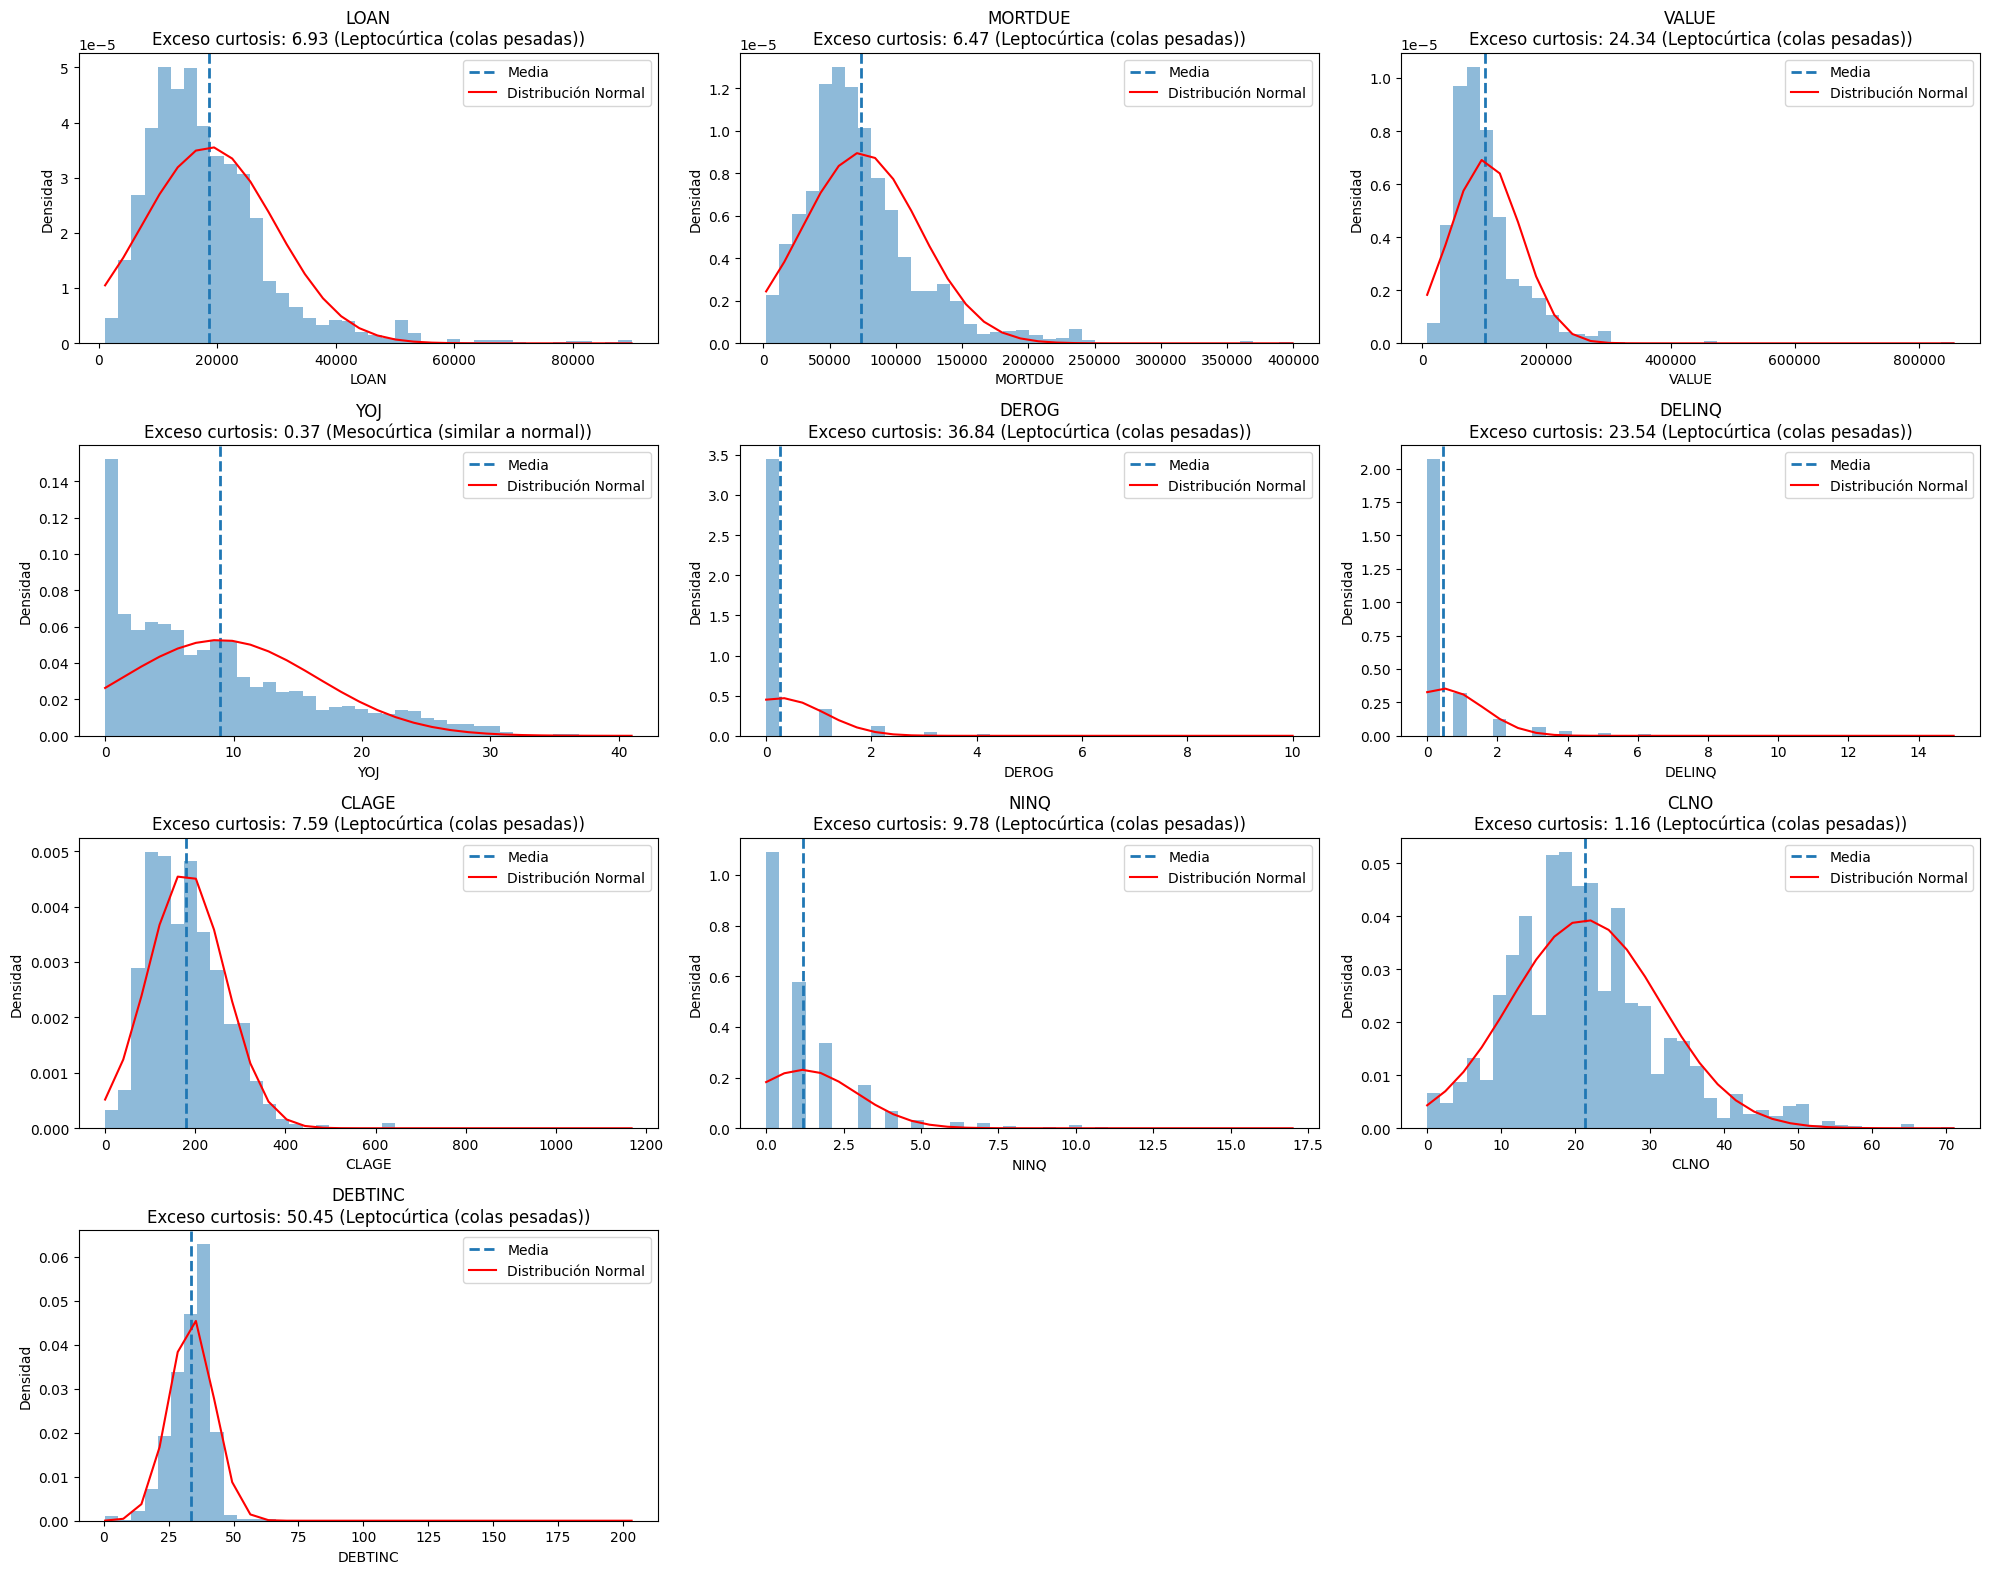

In [11]:
num_cols = ["DEROG", "DELINQ","NINQ","DEBTINC","YOJ", "LOAN", "MORTDUE", "VALUE",   "CLAGE",  "CLNO"]
num_vars = hmeq.select_dtypes(include="number").drop(columns="BAD") # Excluimos la variable objetivo

def kurtosis_type(excess_kurt): # Clasificacion del tipo de curtosis (opcional)
    """
    Clasifica la distribución según la curtosis en exceso
    """
    if excess_kurt > 0.5:
        return "Leptocúrtica (colas pesadas)"
    elif excess_kurt < -0.5:
        return "Platicúrtica (aplanada)"
    else:
        return "Mesocúrtica (similar a normal)"

# Visualización de histogramas con ajuste de distribución normal y clasificación de curtosis
fig, axes = plt.subplots(4,3, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(num_vars.columns):
    # Eliminamos valores nulos
    num_vars_sin_nulos = num_vars[col].dropna()
    mean = num_vars_sin_nulos.mean()
    std = num_vars_sin_nulos.std()
    # Calculamos curtosis en exceso
    excess_kurt = kurtosis(num_vars_sin_nulos, fisher=True)
    dist_type = kurtosis_type(excess_kurt)
    # Clasificamos la distribución
    ax = axes[i]

# Histograma normalizado
    ax.hist(num_vars_sin_nulos, bins=40, density=True, alpha=0.5)
    ax.axvline(mean, linestyle="--", linewidth=2, label="Media")
    x = np.linspace(num_vars_sin_nulos.min(), num_vars_sin_nulos.max(), 30)
    y = norm.pdf(x, mean, std)
    ax.plot(x, y, color="red", label="Distribución Normal")
    ax.set_title(
        f"{col}\n"
        f"Exceso curtosis: {excess_kurt:.2f} ({dist_type})"
    )
    ax.set_xlabel(col)
    ax.set_ylabel("Densidad")
    ax.legend()

for j in range(i + 1, len(axes)): ## Ocultamos axes sobrantes (look and feel)
   axes[j].set_visible(False)

plt.tight_layout()
plt.show()

<small>

La inspección visual de los histogramas de **HMEQ** permite identificar varias características habituales en datos de riesgo de crédito. En primer lugar, se observa una **asimetría positiva** en la mayoría de las variables financieras y de comportamiento, como *LOAN*, *MORTDUE*, *VALUE*, *DEBTINC*, *DELINQ* y *NINQ*, con una elevada concentración de observaciones en valores bajos y colas derechas largas.

Asimismo, se aprecia la **presencia de valores extremos (outliers)**, especialmente en los importes monetarios y ratios financieros, lo cual refleja la heterogeneidad del perfil de los prestatarios. Las variables de comportamiento crediticio, como *DEROG*, *DELINQ* y *NINQ*, presentan una **alta frecuencia de valores cero**, indicando que la mayoría de los clientes no registra incidencias negativas, mientras que una minoría concentra un mayor nivel de riesgo.

Por otro lado, variables relacionadas con la antigüedad del historial crediticio o laboral, como *CLAGE* y *YOJ*, muestran distribuciones más dispersas. En conjunto, la heterogeneidad en las escalas y formas de las distribuciones sugiere la conveniencia de aplicar técnicas de normalización o transformaciones en fases posteriores del análisis, especialmente para modelos sensibles a la escala de las variables.

Este análisis exploratorio confirma que las distribuciones observadas son coherentes con un problema real de **scoring crediticio** y permite anticipar decisiones clave en las etapas de preprocesado y modelización.

La curtosis permite identificar variables con colas pesadas, donde eventos poco frecuentes pueden tener un impacto desproporcionado en el riesgo de crédito.
En este caso, confirma la presencia generalizada de colas pesadas y desviaciones significativas respecto a la normalidad, especialmente en variables financieras y de comportamiento crediticio. Este resultado justifica la aplicación de transformaciones y técnicas robustas en la fase de modelización, evitando supuestos de normalidad que no se sostienen empíricamente en carteras crediticias reales.

</small>

#### 3.4 Análisis de calidad del dato

In [12]:
# Análisis de valores nulos
print("Porcentaje de nulos:") 
porcentaje_nulos = ((hmeq.isna().sum().sort_values(ascending=False) / len(hmeq)) * 100).round(2)
porcentaje_nulos_filtrado = porcentaje_nulos[porcentaje_nulos > 0]
print(porcentaje_nulos_filtrado)

Porcentaje de nulos:
DEBTINC    21.26
DEROG      11.88
DELINQ      9.73
MORTDUE     8.69
YOJ         8.64
NINQ        8.56
CLAGE       5.17
JOB         4.68
REASON      4.23
CLNO        3.72
VALUE       1.88
dtype: float64


<Axes: >

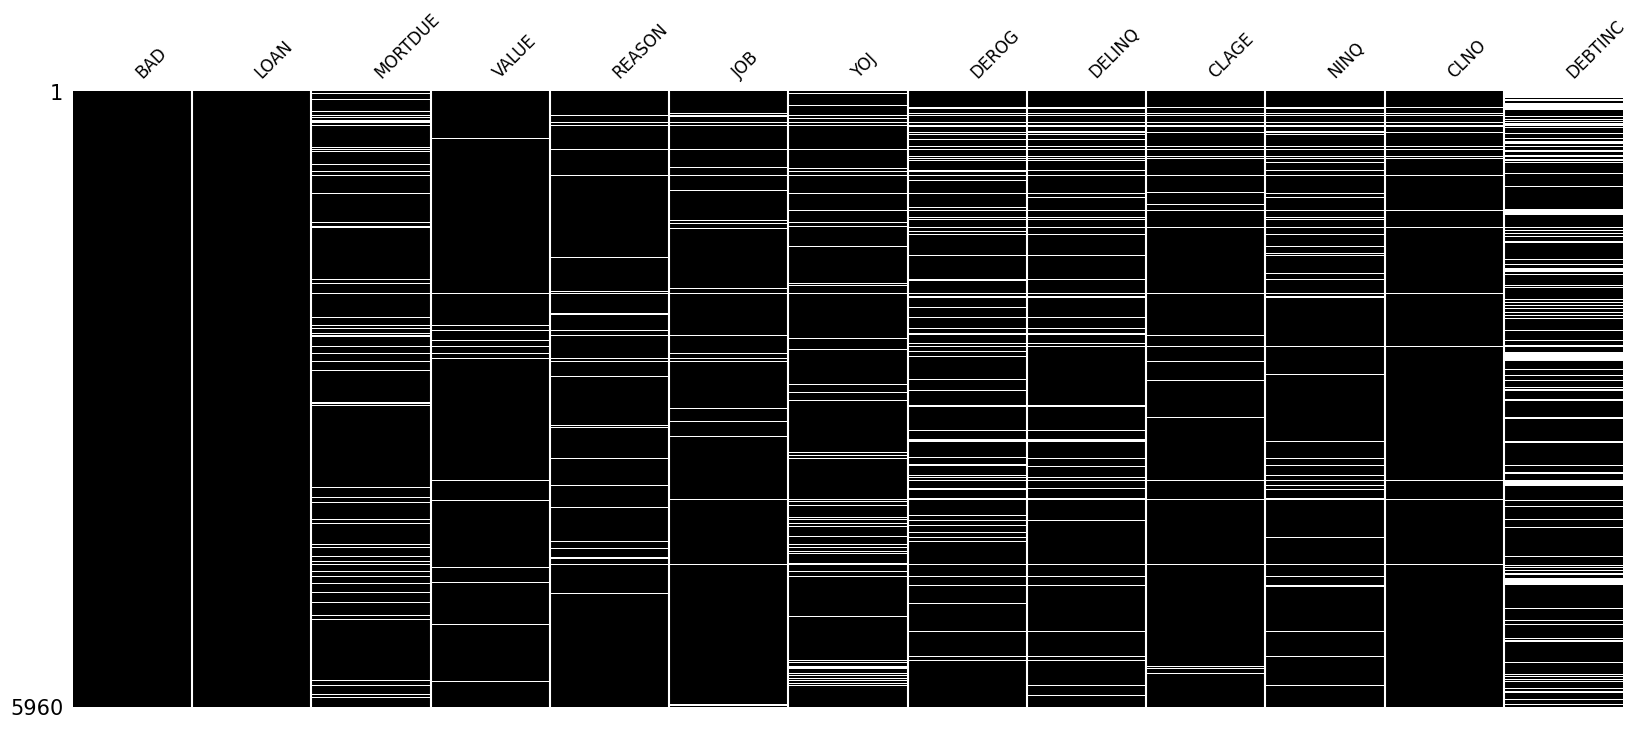

In [13]:
# Crear un mapa de valores faltantes
msno.matrix(hmeq, figsize=(20, 8), color=(0, 0, 0), fontsize=12, sparkline=False)

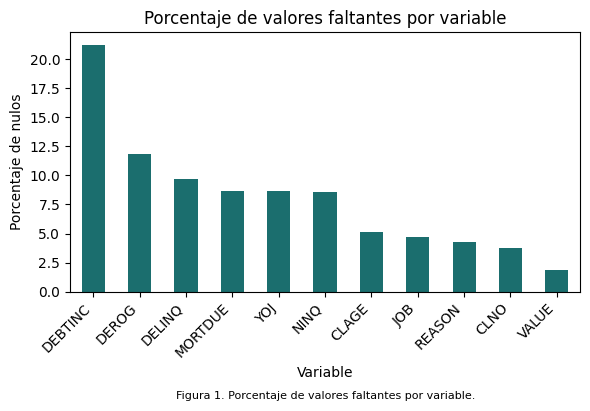

In [14]:
# Gráfico de barras del % de nulos
plt.figure(figsize=(6, 4))
porcentaje_nulos_filtrado.plot(kind="bar", color="#1B6E6E")
plt.title("Porcentaje de valores faltantes por variable")
plt.xlabel("Variable")
plt.ylabel("Porcentaje de nulos")
plt.xticks(rotation=45, ha="right")
plt.figtext(0.8, -0.01,
            "Figura 1. Porcentaje de valores faltantes por variable.",
            ha="right", fontsize=8)
plt.tight_layout()
plt.show()

<small>

- Los datos presentan missing values en la mayoría de variables a excepción de LOAN y BAD. Especial atención DEBTINC o ratio deuda-ingresos donde hay 21.26% de valores faltantes. Esta situación es coherente con la realidad bancaria, donde la información de ingresos puede no estar disponible, ser incompleta o no verificable en determinados clientes.

- Variables de comportamiento crediticio como DEROG (derogatory reports, 12 %) y DELINQ (delinquencies, 10 %) también presentan missing values, lo que resulta especialmente relevante desde una perspectiva de riesgo, al tratarse de indicadores clave para la identificación de historiales de mora o incidencias graves.

- La presencia de nulos en este tipo de variables sugiere que **los valores faltantes no pueden asumirse como completamente aleatorios**, por lo que su tratamiento deberá evaluarse cuidadosamente en la fase de preprocesamiento. 

- En esta sección se analizan los posibles mecanismos de generación de valores faltantes (MCAR, MAR y MNAR), cuya correcta identificación resulta crítica para evitar sesgos en la estimación de la Probabilidad de Incumplimiento (PD).
    - **MCAR** considera que la razón de tener missing es completamente aleatoria. No resulta consistente porque, como hemos mencionado, puede haber dificulta para verificar ingresos o falta de historial crediticio del cliente. Este mecanismo podría afectar puntualmente a variables como CLAGE, CLNO o VALUE, especialmente cuando la información procede de sistemas históricos heterogéneos o de fuentes externas. En este caso, la ausencia de información no estaría correlacionada ni con el incumplimiento (BAD) ni con otras variables explicativas del dataset.
    - **MAR**: la ausencia de información puede estar condicionada por otras características observables del cliente incluidas en el dataset. El missing en DEBTINC puede relacionarse con variables como el empleo (impide determinar el ingreso) o MORTDUE el cual impide determinar la deuda.
    - **MNAR**: La ausencia de información podría estar directamente relacionada con el nivel de riesgo crediticio del cliente.  En este caso, el missing puede contener información implícita de riesgo

</small>

In [15]:
# Análisis de MNAR por su impacto en la variable objetivo
mnar =hmeq.groupby("BAD")[num_cols].apply(lambda x: x.isna().mean() * 100).round(2).transpose().rename(columns={0: "(BAD=0)", 1: "(BAD=1)"})
mnar.round(1).style.format("{:.2f}").background_gradient(cmap="BuGn")

BAD,(BAD=0),(BAD=1)
DEROG,13.00,7.30
DELINQ,10.60,6.10
NINQ,9.10,6.30
DEBTINC,10.10,66.10
YOJ,9.40,5.50
LOAN,0.00,0.00
MORTDUE,8.60,8.90
VALUE,0.20,8.80
CLAGE,4.80,6.60
CLNO,3.50,4.50


<small>

- En clientes que entran en default, el Debt-to-Income Ratio no está disponible en 2/3 de los casos.  Es MNAR y por lo tanto, un indicativo de riesgo
- Su tratamiento será tenido en cuenta en el preprocesamiento evitando imputaciones aleatorias sobre todo en variables que estan asociadas a un mayor nivel de incumplimiento. 
- En menor medida, VALUE es MCAR (0,15 buenos vs 8,83 malos)
- Se descarta como MNAR DEROG, DELINQ Y NINQ.

</small>

In [16]:
# Análisis MAR
cols_missing = [c for c in hmeq.columns if hmeq[c].isna().any()]

matriz = pd.DataFrame(index=cols_missing, columns=cols_missing, dtype=float)
for a in cols_missing:
    for b in cols_missing:
        matriz.loc[a, b] = hmeq[hmeq[a].isna()][b].isna().mean() *100

matriz.round(1).style.format("{:.1f}").background_gradient(cmap="BuGn")

,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
MORTDUE,100.0,5.2,16.0,18.9,37.8,31.1,34.6,20.3,31.3,15.6,22.4
VALUE,24.1,100.0,17.9,15.2,10.7,25.0,21.4,17.0,17.0,16.1,72.3
REASON,32.9,7.9,100.0,42.5,41.3,37.3,38.1,42.1,38.9,33.7,22.2
JOB,35.1,6.1,38.4,100.0,35.8,51.6,47.3,55.2,51.6,47.3,16.1
YOJ,38.1,2.3,20.2,19.4,100.0,34.4,37.7,26.0,37.3,22.7,16.7
DEROG,22.7,4.0,13.3,20.3,25.0,100.0,71.0,31.4,56.8,31.4,18.4
DELINQ,30.9,4.1,16.6,22.8,33.4,86.7,100.0,38.3,73.6,38.3,17.9
CLAGE,34.1,6.2,34.4,50.0,43.5,72.1,72.1,100.0,72.1,72.1,26.3
NINQ,31.8,3.7,19.2,28.2,37.6,78.8,83.7,43.5,100.0,43.5,18.4
CLNO,36.5,8.1,38.3,59.5,52.7,100.0,100.0,100.0,100.0,100.0,26.1


La matriz muestra, para cada par de variables, el porcentaje de registros en los que ambas son missing a la vez.

- DEROG, DELINQ, NINQ y CLNO son MAR y están relacionadas 
- DEBTINC apenas coincide con el resto (4–26 %): su ausencia es independiente y, al concentrarse en los impagos, es coherente con un mecanismo MNAR.

In [17]:
# Resumen de missing values
glob = (hmeq.isna().mean() * 100).round(2)    
bad0 = (hmeq[hmeq["BAD"]==0].isna().mean() * 100).round(2)    
bad1 = (hmeq[hmeq["BAD"]==1].isna().mean() * 100).round(2)   

tabla = pd.DataFrame({
    "% Missing global": glob,
    "% Missing BAD=0": bad0,
    "% Missing BAD=1": bad1,
})

mecanismo = {
    "DEBTINC":"MNAR", "VALUE":"MNAR",
    "DEROG":"MAR", "DELINQ":"MAR", "NINQ":"MAR", "CLNO":"MAR",
    "MORTDUE":"MCAR", "YOJ":"MCAR", "JOB":"MCAR", "REASON":"MCAR","CLAGE":"MCAR",
    "BAD":"N/A", "LOAN":"N/A",
}
tabla["Mecanismo"] = tabla.index.map(mecanismo)

tabla.sort_values("% Missing global", ascending=False)
tabla_final = tabla.sort_values("% Missing global", ascending=False)
num = ["% Missing global", "% Missing BAD=0", "% Missing BAD=1"]

tabla_final.style.format("{:.2f}", subset=num, na_rep="—").background_gradient(cmap="BuGn", subset=["% Missing BAD=1"])



,% Missing global,% Missing BAD=0,% Missing BAD=1,Mecanismo
DEBTINC,21.26,10.08,66.11,MNAR
DEROG,11.88,13.02,7.32,MAR
DELINQ,9.73,10.65,6.06,MAR
MORTDUE,8.69,8.64,8.92,MCAR
YOJ,8.64,9.43,5.47,MCAR
NINQ,8.56,9.12,6.31,MAR
CLAGE,5.17,4.82,6.56,MCAR
JOB,4.68,5.37,1.93,MCAR
REASON,4.23,4.28,4.04,MCAR
CLNO,3.72,3.54,4.46,MAR


In [18]:
# Valores extremos
# Cálculo del rango intercuartílico
outliers_iqr = {}

for col in num_vars: # num_vars calculada anteriormente
    q1 = hmeq[col].quantile(0.25)
    q3 = hmeq[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr # Valor de referencia 1.5 veces el IQR
    upper = q3 + 1.5 * iqr
    
    outliers_iqr[col] = ((hmeq[col] < lower) | (hmeq[col] > upper)).mean() * 100

df_outliers = pd.DataFrame.from_dict(
    outliers_iqr, orient="index", columns=["pct_outliers_IQR"]
).round(2)

df_outliers.sort_values("pct_outliers_IQR", ascending=False)


,pct_outliers_IQR
DELINQ,20.15
DEROG,12.16
VALUE,5.37
LOAN,4.30
MORTDUE,3.93
CLNO,3.67
NINQ,2.97
DEBTINC,1.58
YOJ,1.53
CLAGE,0.79


In [19]:
# % de BAD en valores extremos percentil 75 - 100 
resultados_outliers = []

for col in num_vars:
    q1 = hmeq[col].quantile(0.25)
    q3 = hmeq[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    outliers = hmeq[hmeq[col] > upper]
    no_outliers = hmeq[hmeq[col] <= upper]
    if len(outliers) > 0:
        tasa_bad_outliers = outliers['BAD'].mean() * 100
        tasa_bad_normal = no_outliers['BAD'].mean() * 100
        n_outliers = len(outliers)

        resultados_outliers.append({
            'Variable': col,
            '% outliers': round(n_outliers / len(hmeq) * 100, 2),
            'Tasa BAD outliers (%)': round(tasa_bad_outliers, 2),
            'Tasa BAD normal (%)': round(tasa_bad_normal, 2),
            'Diferencia (pp)': round(tasa_bad_outliers - tasa_bad_normal, 2)
        })

df_bad_outliers = pd.DataFrame(resultados_outliers)
df_bad_outliers = df_bad_outliers.sort_values('Diferencia (pp)', ascending=False)
df_bad_outliers.style.format("{:.2f}", subset=df_bad_outliers.columns[1:]).background_gradient(cmap="BuGn", subset=["Diferencia (pp)"])


,Variable,% outliers,Tasa BAD outliers (%),Tasa BAD normal (%),Diferencia (pp)
9,DEBTINC,0.59,100.00,7.90,92.10
4,DEROG,12.16,48.00,16.66,31.34
5,DELINQ,20.15,44.46,13.95,30.51
7,NINQ,2.97,44.63,19.63,25.00
8,CLNO,3.67,25.57,19.57,6.00
1,MORTDUE,3.93,23.93,19.72,4.21
0,LOAN,4.30,22.27,19.85,2.42
2,VALUE,5.37,20.31,18.43,1.88
3,YOJ,1.53,15.38,20.73,-5.35
6,CLAGE,0.79,6.38,19.77,-13.39


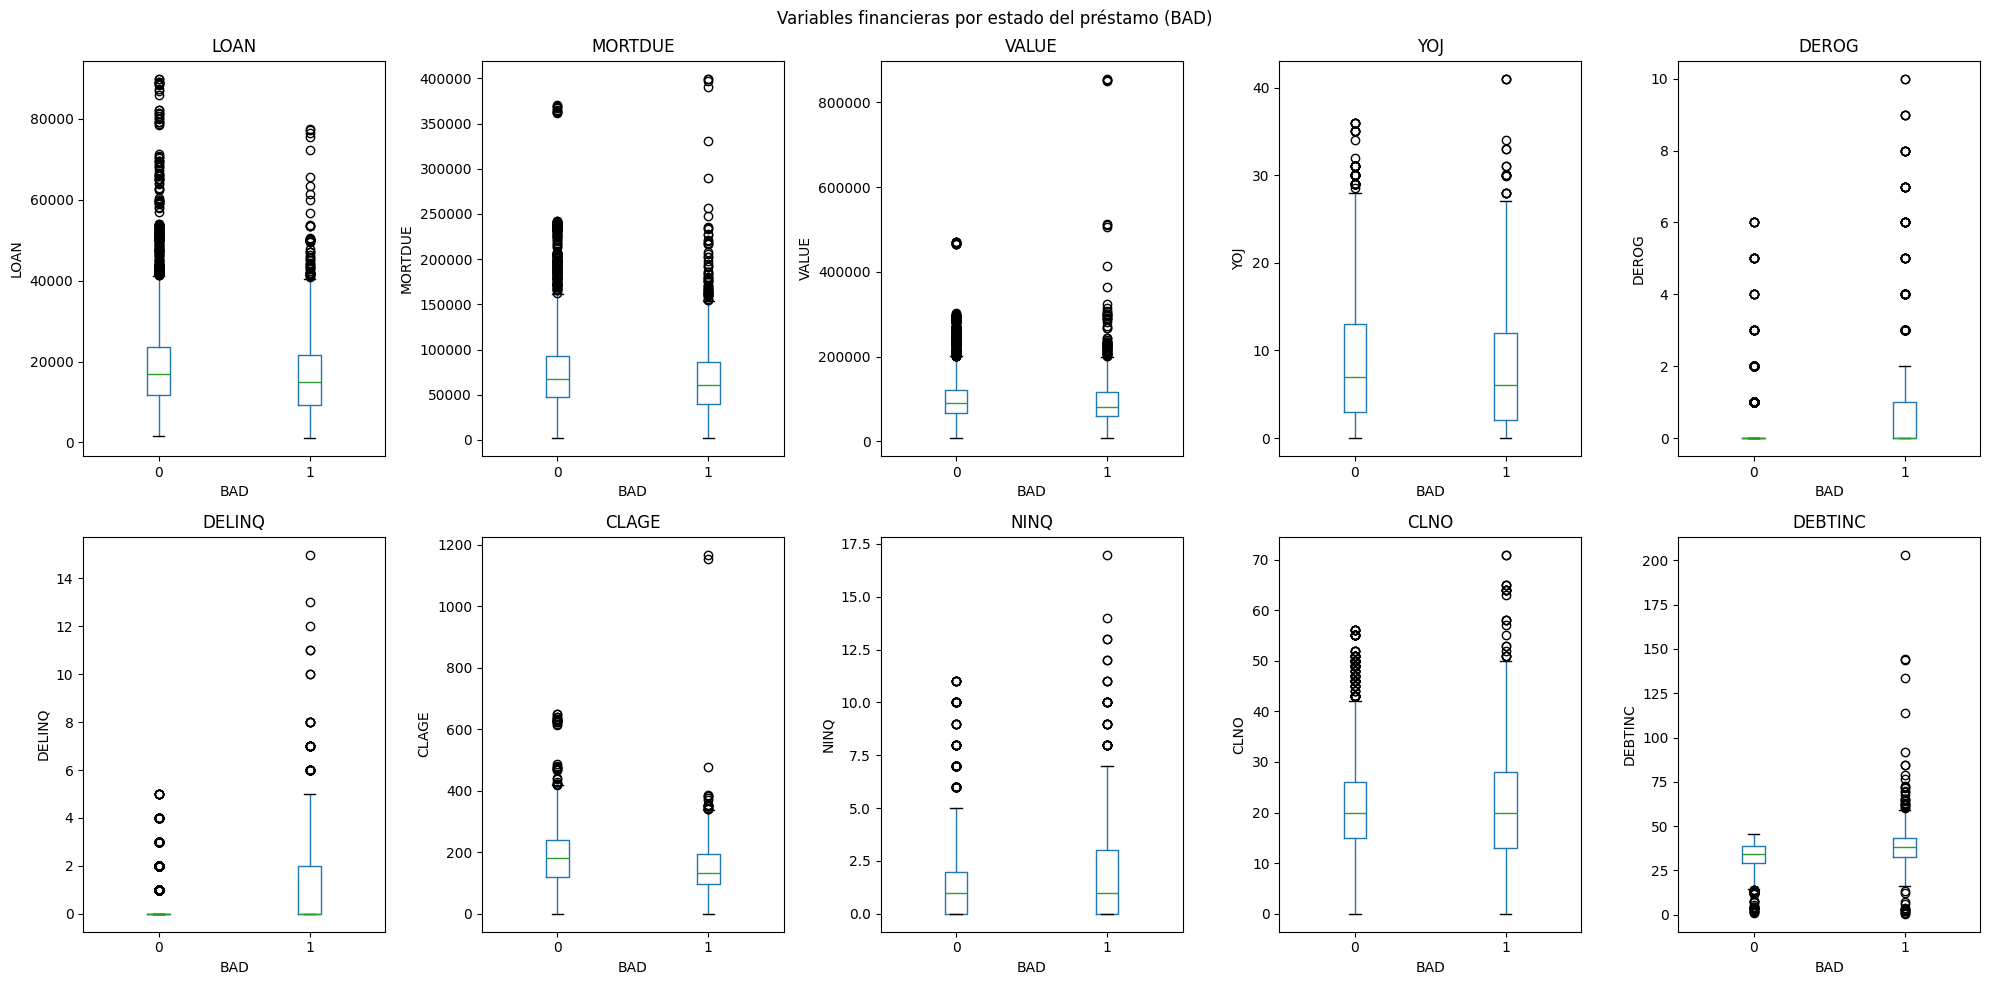

In [20]:
# Visualización 
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for ax, var in zip(axes, num_vars):
    hmeq.boxplot(column=var, by="BAD", ax=ax, grid=False)
    ax.set_title(var)
    ax.set_xlabel("BAD")
    ax.set_ylabel(var)

fig.suptitle("Variables financieras por estado del préstamo (BAD)")
plt.tight_layout()
plt.show()

<small>

- La segmentación de los valores extremos por la variable objetivo (BAD) muestra que, en la mayoría de variables de comportamiento crediticio, los outliers presentan una tasa de impago muy superior a la del resto de registros. El caso más marcado es DEBTINC, cuyos outliers tienen una tasa de impago del 100 % frente al 7,9 % del resto; le siguen DEROG (+31 pp), DELINQ (+31 pp) y NINQ (+25 pp).
- Este patrón indica que, en estas variables, los outliers contienen información de riesgo y no responden a errores de calidad del dato, sino a situaciones crediticias adversas. No obstante, no es un comportamiento universal: en YOJ y CLAGE los outliers presentan una tasa de impago inferior a la media, por lo que la asociación outlier-riesgo es específica de cada variable.
- En consecuencia, en la fase de preprocesamiento no se eliminan los valores extremos, con el objetivo de preservar la señal de riesgo y no deteriorar la capacidad predictiva del modelo.  

</small>

#### 3.5 Análisis multivariante.

Aprovechando la visualización boxplot, podemos apreciar que las variable de comportamiento crediticio muestran una clara separación entre préstamos al corriente y en incumplimiento. Los clientes con valores más elevados en estas variables presentan una mayor probabilidad de default, confirmando su papel como drivers fundamentales del riesgo de crédito. 
Del mismo modo en sentido contrario, variables de estabilidad YOJ e historial crediticio presenta valores mas bajos en aquellos registros en incumplimineto.  
Por lo tanto una conclusión a tener en cuenta es:  
    - Variables asociadas a un menor riesgo: CLAGE y YOJ  
    - Variables asociadas a un mayor riesgo: DEBTINC, DELINQ, DEROG y NINQ

In [21]:
num_vars_target

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882


In [22]:
# Matriz de correlaciones
spearman_corr = num_vars_target.corr(method='spearman')
spearman_corr

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
BAD,1.000000,-0.108399,-0.076588,-0.076722,-0.056740,0.273529,0.332165,-0.186308,0.151596,-0.014937,0.146448
LOAN,-0.108399,1.000000,0.198513,0.345843,0.092240,0.007437,-0.061409,0.122700,0.043359,0.143107,0.120495
MORTDUE,-0.076588,0.198513,1.000000,0.861173,-0.058010,-0.039245,-0.027094,0.131229,0.055517,0.346071,0.180289
VALUE,-0.076722,0.345843,0.861173,1.000000,0.031962,-0.054440,-0.036480,0.193142,0.012652,0.364094,0.166389
YOJ,-0.056740,0.092240,-0.058010,0.031962,1.000000,-0.066582,0.028961,0.172755,-0.061186,0.045379,-0.065466
DEROG,0.273529,0.007437,-0.039245,-0.054440,-0.066582,1.000000,0.240796,-0.085370,0.171612,0.041252,0.013896
DELINQ,0.332165,-0.061409,-0.027094,-0.036480,0.028961,0.240796,1.000000,-0.000471,0.077324,0.147825,0.045863
CLAGE,-0.186308,0.122700,0.131229,0.193142,0.172755,-0.085370,-0.000471,1.000000,-0.098424,0.241881,0.008436
NINQ,0.151596,0.043359,0.055517,0.012652,-0.061186,0.171612,0.077324,-0.098424,1.000000,0.149025,0.205032
CLNO,-0.014937,0.143107,0.346071,0.364094,0.045379,0.041252,0.147825,0.241881,0.149025,1.000000,0.191757


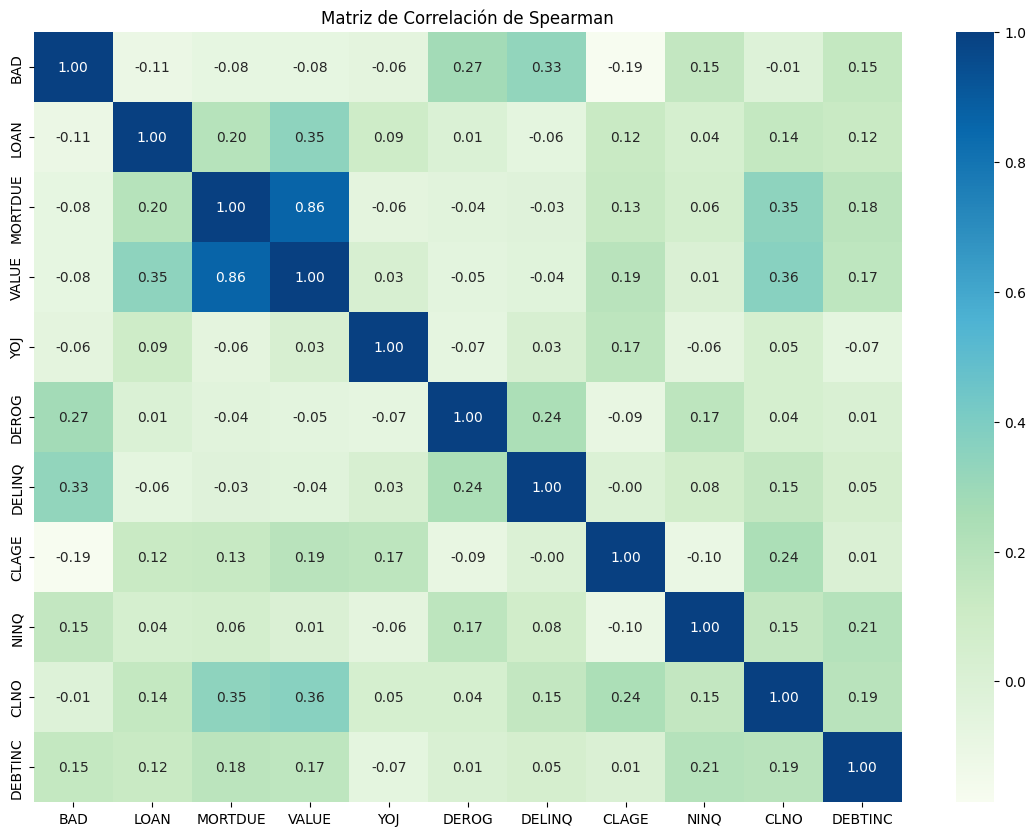

In [23]:
# Visualización de la matriz de correlaciones Spearman
plt.figure(figsize = (14,10)) 
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="GnBu")
plt.title("Matriz de Correlación de Spearman")
plt.show()

- Se ha utilizado la correlación de Spearman para medir la correlación entre variables e identificar posibles problemas de colinealidad entre las features. Esta correlación mide la asociación monótona y es más robusto en distribuciones asimétricas y outliers (algo que ocurre en nuestros datos de crédito).
- La correlación es elevada en dos variables, el saldo hipotecario pendiente (MORTDUE) y el valor del inmueble (VALUE) con un coeficiente ρ ≈ 0.86. Esta correlación es coherente desde el punto de vista económico pero puede generar problemas de colinealidad y por lo tanto la capacidad explicativa del modelo se puede ver comprometida. 
- En el resto de variables no se observa correlación elevada
- Desde el punto de vista del preprocesamiento, estos resultados indican la conveniencia de no incluir simultáneamente MORTDUE y VALUE en el modelo. Como alternativa, se plantea la transformación de ambas variables en un ratio financiero, como el **Loan-to-Value (LTV)**, práctica habitual en la modelización del riesgo de crédito. El resto de variables puede mantenerse sin ajustes adicionales por colinealidad.

In [24]:
cat_vars = hmeq.select_dtypes(include="object")

In [25]:
cat_vars.describe()

,REASON,JOB
count,5708,5681
unique,2,6
top,DebtCon,Other
freq,3928,2388


In [26]:
# Análisis de variables categóricas respecto a la variable objetivo
cat_vars = hmeq.select_dtypes(include="object").columns
for var in ["REASON", "JOB"]:
    display(
        hmeq
        .groupby(var)["BAD"]
        .agg(
            n_obs="count",
            default_rate="mean"
        )
        .assign(default_rate=lambda x: (x["default_rate"] * 100).round(2))
        .sort_values("default_rate", ascending=False)
    )


,n_obs,default_rate
REASON,,
HomeImp,1780,22.25
DebtCon,3928,18.97


,n_obs,default_rate
JOB,,
Sales,109,34.86
Self,193,30.05
Mgr,767,23.34
Other,2388,23.20
ProfExe,1276,16.61
Office,948,13.19


In [27]:
resultados_cat = {}

for var in ["REASON", "JOB"]:
    resultados_cat[var] = (
        hmeq
        .groupby(var)["BAD"]
        .agg(n_obs="count", default_rate="mean")
        .assign(default_rate=lambda x: (x["default_rate"] * 100).round(2))
        .sort_values("default_rate", ascending=False)
        .reset_index()
        .rename(columns={
            var: "Categoría",
            "n_obs": "N observaciones",
            "default_rate": "Tasa de impago (%)"
        })
    )

resultados_cat

{'REASON':   Categoría  N observaciones  Tasa de impago (%)
 0   HomeImp             1780               22.25
 1   DebtCon             3928               18.97,
 'JOB':   Categoría  N observaciones  Tasa de impago (%)
 0     Sales              109               34.86
 1      Self              193               30.05
 2       Mgr              767               23.34
 3     Other             2388               23.20
 4   ProfExe             1276               16.61
 5    Office              948               13.19}

- En relación a la finalidad del prestamo, la diferencia de default es moderada, por lo que  la consideraremos para el modelo aunque con capacidad limitada. 
- Es relevante el tipo de empleo ya que ventas y autonomos tienen asignado una mayor probabilidad de default. 
- En el preprocesamiento, se usará One Hot enconding ya que no impone jerarquia y no son muchas categorias (2 y 6, respectivamente)

#### 3.6 Síntesis del EDA

El análisis exploratorio caracteriza la estructura del dataset HMEQ y fija las decisiones de preprocesamiento que alimentan la modelización.

**Variable objetivo.** BAD presenta un desbalance significativo (en torno al 20 % de impago), consistente con carteras reales de crédito retail. Esto descarta métricas como el accuracy y orienta la evaluación hacia discriminación (AUC, Gini, KS) y calibración (Brier, curva de calibración).

**Distribuciones y outliers.** La mayoría de variables financieras y de comportamiento muestran asimetría positiva, colas derechas largas y curtosis elevada. Los valores extremos se concentran en clientes en incumplimiento (señal de riesgo, no ruido), con las excepciones de CLAGE y YOJ, donde los extremos actúan como factor protector. Por ello los outliers se conservan.

**Calidad del dato (mecanismos de ausencia).** Los valores faltantes no son completamente aleatorios. Se identifican mecanismos MNAR (DEBTINC, VALUE), MAR (DEROG, DELINQ, NINQ, CLNO) y MCAR (resto). El tratamiento preserva la señal del patrón de ausencia y difiere por modelo: tramo de missing en el binning WoE (modelo principal), gestión nativa de NaN (LightGBM) e imputación por mediana calculada solo en train (XGBoost).

> **El caso DEBTINC.** Es la variable más singular del dataset desde el EDA: ausencia MNAR muy marcada (66 % de missing en impagos frente al 10 % en no impagos), la mayor curtosis (50,45) y una cola superior con tasa de impago del 100 %. La ausencia del dato es, en sí misma, información de riesgo. Su tratamiento como predictor y la verificación de que no introduce data leakage se desarrollan en el Capítulo 5.

**Multivariante y CLTV.** La correlación de Spearman detecta una dependencia elevada entre MORTDUE y VALUE (ρ = 0,86), por encima del umbral |ρ| > 0,7. Para resolver la colinealidad se construye el ratio Combined Loan-to-Value, CLTV = (LOAN + MORTDUE) / VALUE, con cap económico en 2,55, que sustituye a ambas. Tras la transformación, ningún par supera el umbral. La correlación de CLTV con BAD es prácticamente nula y ligeramente negativa (ρ = -0,05), indicio de una relación no monótona que se retoma en el Capítulo 5.

**Variables categóricas.** REASON muestra poder discriminante limitado y se excluye en el Capítulo 5 (respaldado por su IV); JOB discrimina más y se conserva. En los modelos de árboles se codifican con OrdinalEncoder dentro del ColumnTransformer; en el modelo principal, mediante WoE.

**Drivers de riesgo.** El análisis bivariante frente a BAD identifica como principales drivers de default DELINQ, DEROG, NINQ y DEBTINC, y como detractores de riesgo CLAGE y YOJ.

**Paso a la modelización.** Sobre esta base se construyen tres modelos: un modelo principal (Regresión Logística + WoE), alineado con el estándar de scorecards y la interpretabilidad regulatoria, y dos benchmark de gradient boosting (LightGBM y XGBoost) para medir el coste en discriminación de optar por un modelo interpretable. La evaluación combina discriminación (AUC, Gini, KS), calibración (Brier, curva de calibración) y estabilidad poblacional (PSI).